# Loan Default Prediction Starter Notebook

## Deep Learning IndabaX Zimbabwe 2026

### Hackathon: Machine Learning and Artificial Intelligence for Zimbabwe's Banking Sector and Financial Inclusion

### Preparing Zimbabwe's Workforce for an AI-Driven Future

## AI for Financial Inclusion — Predicting Loan Defaults in Zimbabwe's Banking Sector

### About the Challenge
Zimbabwe's banking sector faces a persistent challenge: **loan defaults**. When borrowers fail to repay their loans, financial institutions absorb significant losses, which in turn constrains their ability to extend credit to new customers — particularly small and medium enterprises (SMEs), agricultural producers, and individuals in underserved communities.

Accurate prediction of loan default risk is critical for:
- **Reducing financial losses** for banks and microfinance institutions.
- **Expanding access to credit** by enabling more confident lending decisions.
- **Supporting economic growth** across Zimbabwe's diverse provinces and employment sectors.
- **Enabling fair lending** — ensuring creditworthy borrowers are not unfairly denied access.

### Your Task
Build **machine learning models** that predict whether a loan will default based on borrower characteristics, loan terms, and contextual features. Your model should:
- Handle **real-world data quality issues** (missing values, mixed data types).
- Extract **meaningful features** from raw data (dates, categorical variables, interactions).
- Achieve strong **predictive performance** measured by standard classification metrics.
- Produce **predictions on the Test set** and submit them in the format shown in `SampleSubmission.csv`.

You can also compete for **Most Innovative Solution** by integrating your model into a solution that helps the banking sector — for example an add-on to a banking system (risk dashboard, API, plugin) or a core application (loan origination, credit scoring tool). See **Prizes** and **Rules** below for team size (3–5 members) and award details.

### Competition Files

| File | Description |
|------|-------------|
| `Train.csv` | Training data with 38,932 loan records — includes the target `ID` column |
| `Test.csv` | Test data with 12,977 loan records — **`defaulted` column is missing**, you must predict it |
| `SampleSubmission.csv` | Template showing the exact format of your submission (`ID` + `Target`) |
| `VariableDefinitions.csv` | Descriptions of all columns, data types, and value ranges |
| `Starter Notebook.ipynb` | This notebook — a baseline to get you started |

### Dataset Features

| Feature | Description | Type |
|---------|-------------|------|
| `ID` | Unique loan identifier | ID |
| `product_code` | Loan product type (0–5) | Categorical |
| `date_approved` | Loan approval date | Date |
| `date_disbursed` | Loan disbursement date | Date |
| `first_payment_due` | First payment due date | Date |
| `maturity_date` | Loan maturity date | Date |
| `amount_usd` | Loan amount in USD | Numerical |
| `annual_rate_pct` | Annual interest rate (%) | Numerical |
| `term_months` | Loan term in months | Numerical |
| `payment_frequency` | Payment schedule | Categorical |
| `loan_purpose` | Purpose of the loan | Categorical |
| `client_gender` | Borrower gender | Categorical |
| `client_dob` | Borrower date of birth | Date |
| `marital_status` | Borrower marital status | Categorical |
| `num_dependents` | Number of dependents | Numerical |
| `employment_sector` | Borrower's employment sector | Categorical |
| `months_at_employer` | Tenure at current employer | Numerical |
| `monthly_income_usd` | Monthly income in USD | Numerical |
| `existing_obligations` | Number of existing loans | Numerical |
| `collateral_type` | Type of collateral provided | Categorical |
| `disbursement_channel` | How the loan was disbursed | Categorical |
| `province` | Borrower's province | Categorical |
| `Target` | **Target variable** (1 = default, 0 = no default) — **only in Train.csv** | Binary |

**Note:** Both Train and Test datasets contain missing values across several columns — handling these is part of the challenge! The Test set has slightly more missing values to test the robustness of your approach.

### How Submissions Work
1. Train your model on `Train.csv` (use train/validation split for local evaluation).
2. Generate predictions for every `ID` in `Test.csv`.
3. Create a submission file with exactly two columns: `ID` and `Target` (predicted probability or binary 0/1).
4. Your submission must match the format in `SampleSubmission.csv`.
5. Your score on the **public leaderboard** (30% of test data) is visible during the competition.
6. Your final ranking is determined by the **private leaderboard** (70% of test data), revealed after the deadline.

### Evaluation
- **Primary Metric**: ROC-AUC Score
- **Secondary Metrics**: Accuracy, Precision, Recall, F1-Score
- **Leaderboard**: Based on ROC-AUC performance on the test set.

### Impact
By solving this challenge, you will demonstrate how AI can be applied to **real financial problems** in Zimbabwe. The best solutions could inspire tools that help banks make smarter lending decisions, reduce default rates, and ultimately contribute to greater **financial inclusion** across the country.

After this hackathon, participants will be encouraged to be **creative with their models** and think about how they can be deployed in **real-world applications** used by the banking sector — such as loan origination systems, credit scoring platforms, and risk dashboards.

### Prizes
This is a **learning hackathon** focused on skills development, collaboration, and building real-world AI solutions for Zimbabwe's banking sector.

- There are **currently no cash prizes**.
- Teams will still be recognized for **Best Model** and **Most Innovative Solution**.
- Winning teams will:
  - **Present their solutions at Conference**
  - Receive **certifications**
  - Receive **IndabaX T-shirts**

### Timeline
- **Registration opens**: 2 May 2026 (10:00)
- **Hackathon begins**: 9 May 2026 (10:00)
- **Model development phase (ZINDI)**: 9-15 May 2026 (23:59)
- **Practical solution development**: 9-22 May 2026
- **Final submission**: 22 May 2026 (22:59-23:59)
- **Result announcement**: 2 June 2026
- **Award ceremony**: 5 June 2026

### Rules
- This challenge is **only open to the Deep Learning Indaba X Zimbabwe Community**.
- **Team size**: Participants must work in **teams of at least 4 and at most 5** members.
- Teams must adhere to the **code of conduct** and **submission guidelines**.
- Submissions must follow the `SampleSubmission.csv` format exactly.


# Starter Notebook: Loan Default Prediction

## Overview
This notebook serves as a **starter template** for the *AI for Financial Inclusion* hackathon challenge. It provides a foundational workflow for loading, exploring, preprocessing, modelling, and **creating a submission file** for the Zindi-style competition. Use this as a jumping-off point to build and refine your solution.

## Objectives
By the end of this notebook, you will:
1. **Load the competition files**: `Train.csv`, `Test.csv`, and `SampleSubmission.csv`.
2. **Explore the training data**: Understand distributions, missing values, and class balance.
3. **Preprocess data**: Handle missing values, encode categorical features, and engineer new features.
4. **Train a baseline model**: Implement a simple Logistic Regression classifier (with train/validation split).
5. **Evaluate performance**: Calculate metrics (AUC, accuracy, F1-score) on a local validation set.
6. **Generate predictions on Test set**: Create a submission file ready for the leaderboard.


## **Importing Libraries**

In [1]:
import os

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

%matplotlib inline
sns.set_style('whitegrid')

## **Loading the Data**

In [2]:
# Load competition files
train = pd.read_csv('Train.csv')
test = pd.read_csv('Test.csv')
sample_sub = pd.read_csv('SampleSubmission.csv')

print(f"Train shape: {train.shape[0]:,} rows, {train.shape[1]} columns")
print(f"Test shape:  {test.shape[0]:,} rows, {test.shape[1]} columns")
print(f"Sample submission shape: {sample_sub.shape[0]:,} rows, {sample_sub.shape[1]} columns")
print(f"\nTest set has NO 'defaulted' column — that's what you predict!")
print(f"Train columns: {list(train.columns)}")
print(f"Test columns:  {list(test.columns)}")

df = train.copy()
df.head()

Train shape: 38,932 rows, 23 columns
Test shape:  12,977 rows, 22 columns
Sample submission shape: 12,977 rows, 2 columns

Test set has NO 'defaulted' column — that's what you predict!
Train columns: ['ID', 'product_code', 'date_approved', 'date_disbursed', 'first_payment_due', 'maturity_date', 'amount_usd', 'annual_rate_pct', 'term_months', 'payment_frequency', 'loan_purpose', 'client_gender', 'client_dob', 'marital_status', 'num_dependents', 'employment_sector', 'months_at_employer', 'monthly_income_usd', 'existing_obligations', 'collateral_type', 'disbursement_channel', 'province', 'Target']
Test columns:  ['ID', 'product_code', 'date_approved', 'date_disbursed', 'first_payment_due', 'maturity_date', 'amount_usd', 'annual_rate_pct', 'term_months', 'payment_frequency', 'loan_purpose', 'client_gender', 'client_dob', 'marital_status', 'num_dependents', 'employment_sector', 'months_at_employer', 'monthly_income_usd', 'existing_obligations', 'collateral_type', 'disbursement_channel', 'pr

,ID,product_code,date_approved,date_disbursed,first_payment_due,maturity_date,amount_usd,annual_rate_pct,term_months,payment_frequency,...,marital_status,num_dependents,employment_sector,months_at_employer,monthly_income_usd,existing_obligations,collateral_type,disbursement_channel,province,Target
0,CU70100,0,27/1/2026,11/2/2026,23/3/2026,1/2/2028,2239.44,120.41,24,Monthly,...,Married,4.0,Retail_Trade,20.0,612.34,1,NaN,Cash,Masvingo,0
1,BF12802,2,21/11/2025,28/11/2025,28/12/2025,22/5/2027,621.94,130.32,18,Monthly,...,Single,7.0,Informal_Sector,14.0,102.67,3,Property,EcoCash,Mashonaland_East,0
2,ZN77347,1,27/7/2025,28/7/2025,23/8/2025,19/1/2027,3045.52,127.97,18,Monthly,...,Married,3.0,Education,135.0,NaN,1,Guarantor,InnBucks,Harare,0
3,IB09411,1,15/7/2025,22/7/2025,22/8/2025,13/1/2027,9005.01,111.78,18,Bi-Weekly,...,Married,3.0,Informal_Sector,18.0,486.26,3,Vehicle,EcoCash,Matabeleland_South,0
4,HL21785,3,29/11/2024,8/12/2024,10/1/2025,28/11/2026,716.22,15.28,24,Monthly,...,Married,5.0,Retail_Trade,31.0,257.58,4,Property,Cash,Harare,0


For each loan we have:
- **Loan details**: product code, dates (approval, disbursement, first payment, maturity), amount, interest rate, term, payment frequency, purpose, collateral, disbursement channel
- **Borrower details**: gender, date of birth, marital status, number of dependents, employment sector, months at employer, monthly income, existing obligations, province
- **Target** (Train only): `defaulted` (1 = loan defaulted, 0 = loan repaid)

The **Test set** has the same features but **without** the `defaulted` column — your job is to predict it.

## **Exploration, Preprocessing and Feature Engineering**

It is essential to understand the data before diving into modelling. Pay attention to:
- **Missing values** — which columns have them and how many?
- **Class balance** — is the target balanced?
- **Feature distributions** — are there outliers or skewed distributions?

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38932 entries, 0 to 38931
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    38932 non-null  object 
 1   product_code          38932 non-null  int64  
 2   date_approved         38932 non-null  object 
 3   date_disbursed        38932 non-null  object 
 4   first_payment_due     38932 non-null  object 
 5   maturity_date         38932 non-null  object 
 6   amount_usd            38932 non-null  float64
 7   annual_rate_pct       38543 non-null  float64
 8   term_months           38932 non-null  int64  
 9   payment_frequency     38932 non-null  object 
 10  loan_purpose          38154 non-null  object 
 11  client_gender         38932 non-null  object 
 12  client_dob            38932 non-null  object 
 13  marital_status        38349 non-null  object 
 14  num_dependents        36597 non-null  float64
 15  employment_sector  

In [4]:
missing = df.isin(['', None]).sum() + df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
for col, count in missing.items():
    print(f"  {col}: {count} ({100*count/len(df):.1f}%)")

Columns with missing values:
  collateral_type: 12373 (31.8%)
  monthly_income_usd: 3114 (8.0%)
  num_dependents: 2335 (6.0%)
  months_at_employer: 1946 (5.0%)
  employment_sector: 1167 (3.0%)
  loan_purpose: 778 (2.0%)
  marital_status: 583 (1.5%)
  annual_rate_pct: 389 (1.0%)


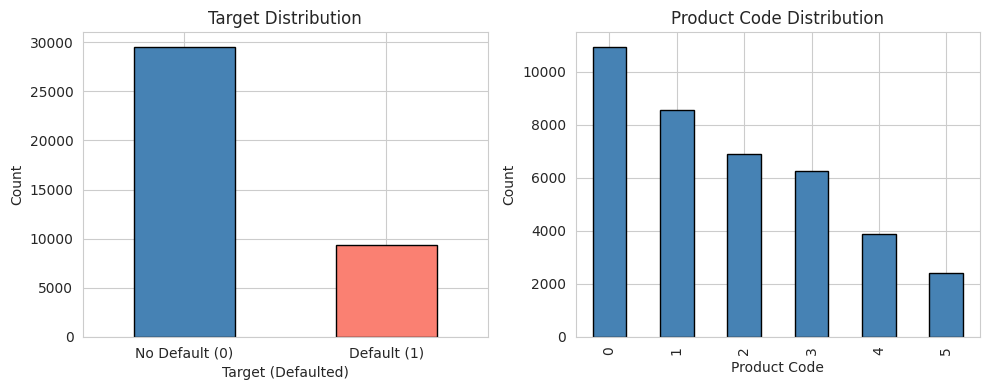

In [5]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
df['Target'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black')
plt.title('Target Distribution')
plt.xlabel('Target (Defaulted)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Default (0)', 'Default (1)'], rotation=0)

plt.subplot(1, 2, 2)
df['product_code'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Product Code Distribution')
plt.xlabel('Product Code')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [6]:
print(f"Default rate: {df['Target'].mean():.1%}")
print(f"\nNumerical columns summary:")
num_cols = ['amount_usd', 'annual_rate_pct', 'term_months', 'monthly_income_usd', 'existing_obligations']
for col in num_cols:
    vals = pd.to_numeric(df[col], errors='coerce')
    print(f"  {col}: mean={vals.mean():.2f}, median={vals.median():.2f}, "
          f"min={vals.min():.2f}, max={vals.max():.2f}, missing={vals.isna().sum()}")

Default rate: 24.1%

Numerical columns summary:
  amount_usd: mean=4753.01, median=2781.47, min=52.02, max=75062.17, missing=0
  annual_rate_pct: mean=69.14, median=80.83, min=8.21, max=202.19, missing=389
  term_months: mean=15.03, median=12.00, min=1.00, max=48.00, missing=0
  monthly_income_usd: mean=543.12, median=442.52, min=31.30, max=2791.72, missing=3114
  existing_obligations: mean=1.90, median=1.00, min=0.00, max=8.00, missing=0


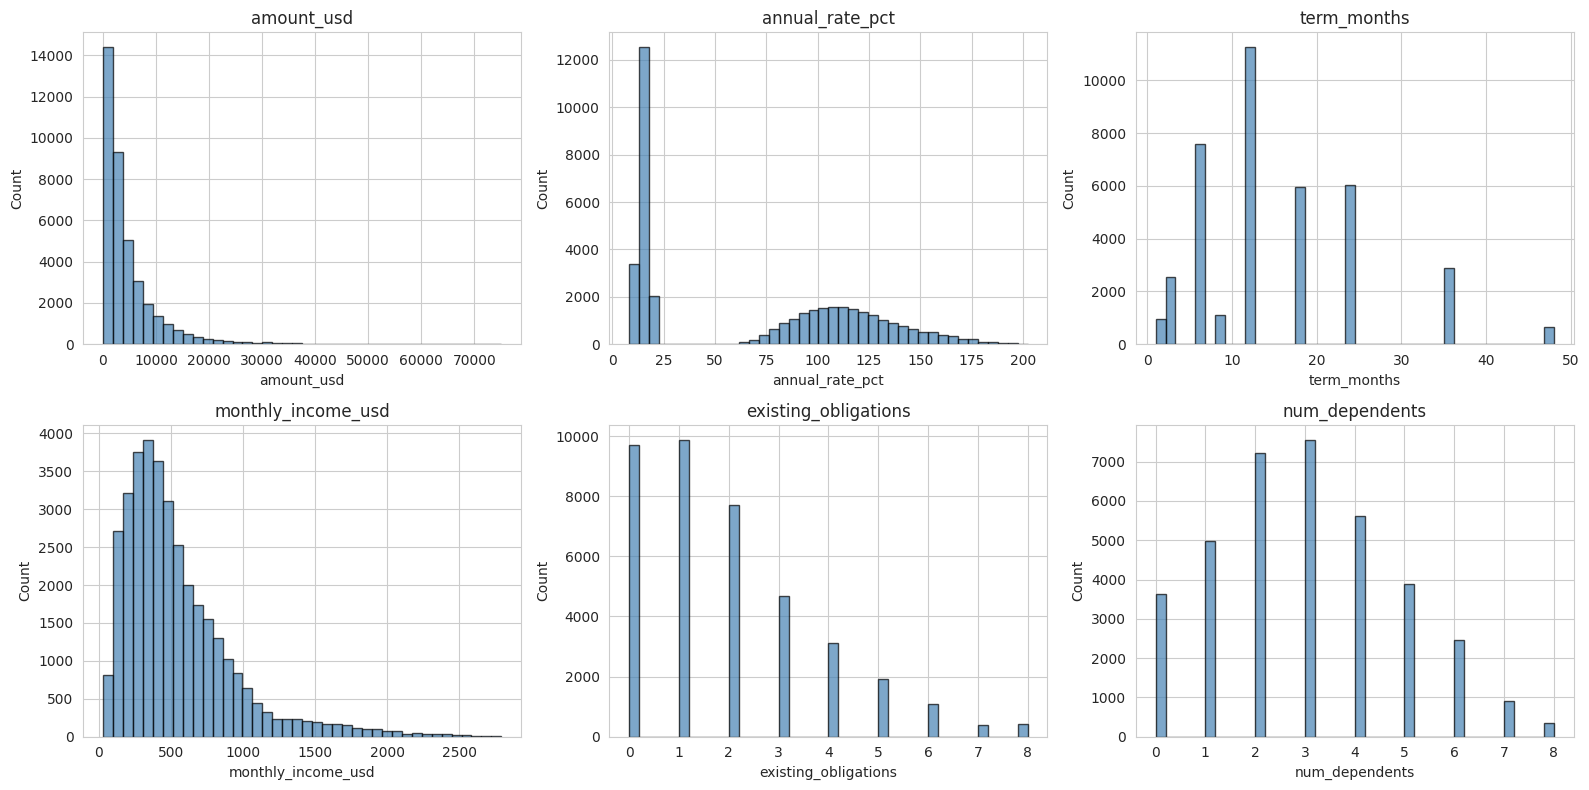

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, col in zip(axes.flat, num_cols + ['num_dependents']):
    vals = pd.to_numeric(df[col], errors='coerce').dropna()
    ax.hist(vals, bins=40, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

### Feature Engineering

We'll create a simple set of features for the baseline. **This is where you can get creative!**
- Engineer features from dates (e.g., loan duration, time to first payment)
- Compute derived ratios (e.g., debt-to-income)
- Encode categorical variables
- Handle missing values with imputation strategies

In [8]:
df_model = df.copy()

# Convert numeric columns (some may be strings due to missing values represented as empty strings)
numeric_features = ['amount_usd', 'annual_rate_pct', 'term_months',
                    'monthly_income_usd', 'existing_obligations',
                    'num_dependents', 'months_at_employer']

for col in numeric_features:
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

# Simple imputation: fill numeric missing values with the median
for col in numeric_features:
    median_val = df_model[col].median()
    df_model[col] = df_model[col].fillna(median_val)

# For this baseline, we'll use just the numerical features
feature_cols = numeric_features

X = df_model[feature_cols]
y = df_model['Target']

print(f"Feature matrix shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")

Feature matrix shape: (38932, 7)
Target distribution:
Target
0    29542
1     9390
Name: count, dtype: int64


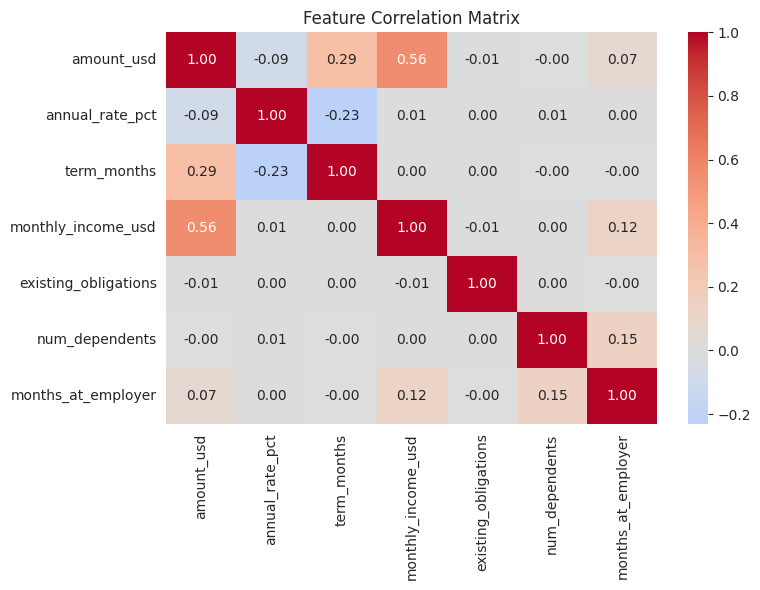

In [9]:
plt.figure(figsize=(8, 6))
sns.heatmap(X.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## **Model Training (Local Validation)**

We split the **training data** into a local train/validation set to estimate how well your model performs before submitting predictions on the Test set.

We train a simple **Logistic Regression** model as a baseline. This gives you a starting point — your goal is to beat this score!

Things to try:
- Add more features (categorical encoding, date features, interactions)
- Try different models (Random Forest, Gradient Boosting, Neural Networks)
- Tune hyperparameters
- Use cross-validation
- Apply techniques for handling class imbalance

In [10]:
# Local train/validation split (NOT the competition test set — that's Test.csv)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Local training set: {X_train.shape[0]:,} samples")
print(f"Local validation set: {X_val.shape[0]:,} samples")
print(f"Train default rate: {y_train.mean():.1%}")
print(f"Validation default rate: {y_val.mean():.1%}")

Local training set: 27,252 samples
Local validation set: 11,680 samples
Train default rate: 24.1%
Validation default rate: 24.1%


In [11]:
model = LogisticRegression(class_weight='balanced', solver='liblinear', max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)
y_proba = model.predict_proba(X_val)[:, 1]

## **Local Evaluation (Validation Set)**

In [12]:
print("=" * 50)
print("BASELINE MODEL PERFORMANCE (Validation Set)")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_val, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_val, y_proba):.4f}")
print(f"F1-Score:  {f1_score(y_val, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=['No Default', 'Default']))

BASELINE MODEL PERFORMANCE (Validation Set)
Accuracy:  0.6036
ROC-AUC:   0.6451
F1-Score:  0.4215

Classification Report:
              precision    recall  f1-score   support

  No Default       0.83      0.61      0.70      8863
     Default       0.33      0.60      0.42      2817

    accuracy                           0.60     11680
   macro avg       0.58      0.60      0.56     11680
weighted avg       0.71      0.60      0.63     11680



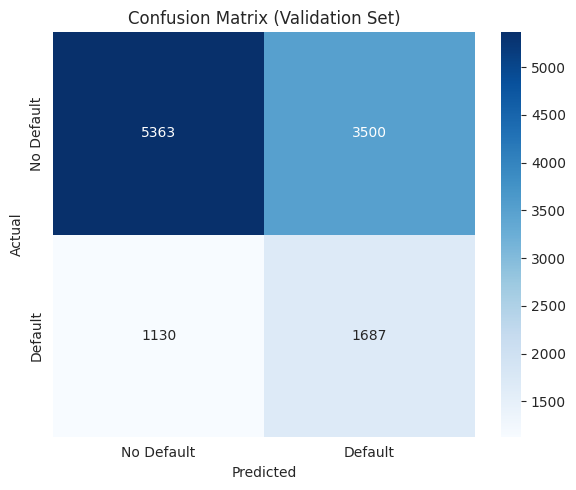

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix (Validation Set)')
plt.tight_layout()
plt.show()

## **Generate Predictions on Test Set & Create Submission**

Now that you've evaluated your model locally, it's time to:
1. **Retrain** the model on the **full training data** (all 38,932 rows) for maximum performance.
2. **Preprocess the Test set** using the same pipeline.
3. **Generate predictions** for every `loan_ref` in `Test.csv`.
4. **Create a submission file** in the format required by `SampleSubmission.csv`.

In [14]:
# Retrain on FULL training data for best performance
model_final = LogisticRegression(class_weight='balanced', solver='liblinear', max_iter=1000)
model_final.fit(X, y)
print(f"Final model trained on {X.shape[0]:,} samples")

Final model trained on 38,932 samples


In [15]:
# Preprocess the Test set using the SAME pipeline as training
test_model = test.copy()

for col in numeric_features:
    test_model[col] = pd.to_numeric(test_model[col], errors='coerce')

# Impute missing values using the TRAINING set medians (no data leakage!)
for col in numeric_features:
    train_median = pd.to_numeric(df_model[col], errors='coerce').median()
    test_model[col] = test_model[col].fillna(train_median)

X_test_final = test_model[feature_cols]
print(f"Test feature matrix shape: {X_test_final.shape}")
print(f"Any NaN remaining: {X_test_final.isna().sum().sum()}")

Test feature matrix shape: (12977, 7)
Any NaN remaining: 0


In [16]:
# Generate predictions on the Test set
test_predictions = model_final.predict_proba(X_test_final)[:, 1]

# Create submission file
submission = pd.DataFrame({
    'ID': test['ID'],
    'Target': test_predictions
})

# Verify format matches SampleSubmission
assert list(submission.columns) == list(sample_sub.columns), "Column mismatch!"
assert len(submission) == len(sample_sub), "Row count mismatch!"

submission.to_csv('submission.csv', index=False)
print(f"Submission saved to 'submission.csv'")
print(f"Shape: {submission.shape}")
print(f"\nFirst 5 rows:")
submission.head()

Submission saved to 'submission.csv'
Shape: (12977, 2)

First 5 rows:


,ID,Target
0,DFO6773,0.586353
1,ACG1537,0.516090
2,DQL8503,0.443942
3,SIM5667,0.378462
4,CGP5642,0.409833


Prediction distribution:
  Mean predicted probability: 0.4828
  Min: 0.0699
  Max: 0.8140
  Predicted default rate (>0.5): 45.1%


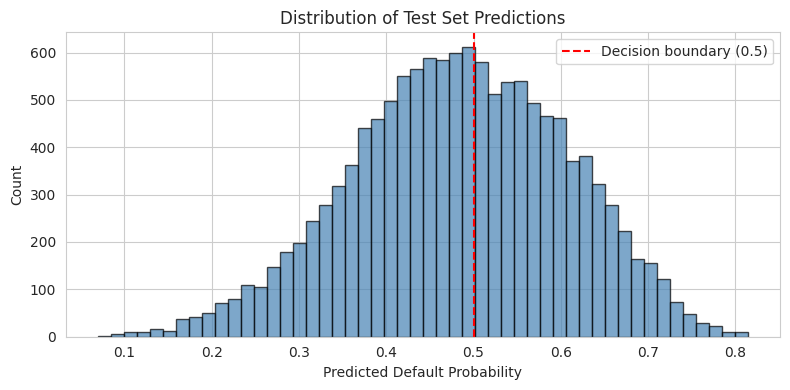

In [17]:
# Quick sanity check on predictions
print("Prediction distribution:")
print(f"  Mean predicted probability: {test_predictions.mean():.4f}")
print(f"  Min: {test_predictions.min():.4f}")
print(f"  Max: {test_predictions.max():.4f}")
print(f"  Predicted default rate (>0.5): {(test_predictions > 0.5).mean():.1%}")

plt.figure(figsize=(8, 4))
plt.hist(test_predictions, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Predicted Default Probability')
plt.ylabel('Count')
plt.title('Distribution of Test Set Predictions')
plt.axvline(x=0.5, color='red', linestyle='--', label='Decision boundary (0.5)')
plt.legend()
plt.tight_layout()
plt.show()

## **Next Steps — Beat This Baseline!**

This baseline uses only a handful of numerical features with simple median imputation. There is **a lot of room for improvement**:


### Submission Tips
- Your submission must match `SampleSubmission.csv` format exactly: `loan_ref` and `defaulted`
- You can submit **predicted probabilities** (float between 0 and 1) or **binary predictions** (0 or 1) — probabilities generally score better on ROC-AUC
- The **public leaderboard** shows your score on 30% of the test data
- The **private leaderboard** (70%) determines your final ranking — avoid overfitting to the public score!

### Most Innovative Solution Award
Think about how your model could be **deployed in a real-world banking application**:
- A **loan origination system** that scores applications in real-time
- A **risk dashboard** for bank managers
- A **mobile app** for loan officers in the field
- An **API service** that integrates with existing banking infrastructure
- A **credit scoring platform** for microfinance institutions

The "Most Innovative Solution" prize goes to the team that best demonstrates how their model can be integrated into a working application for Zimbabwe's banking sector.

**Good luck! Build something amazing for Zimbabwe's banking sector.**

## Contact & Collaboration

For collaborations and inquiries:
- **info@indabaxzimbabwe.com**
- **shannon@indabaxzimbabwe.com**

## Winner Recognition

Although this is a **learning hackathon** with no current cash prizes, winning teams will:
- Present their solutions at **Conference**
- Receive **certifications**
- Receive **IndabaX T-shirts**